# HARIBON Objective 2 – LSTM Red Tide Risk Prediction

**Goal:** Train a binary-classification LSTM to predict next-day red-tide risk from multi-source oceanographic/atmospheric features.

**Pipeline steps:**
1. Data loading & exploration
2. Hybrid Gap-Adaptive Imputation (micro / block / seasonal)
3. Label binarisation & feature selection
4. Rolling-Origin Cross-Validation with sliding-window sequence generation
5. LSTM with Binary Focal Loss
6. Per-split & aggregate metric reporting

In [35]:
# ──────────────────────────────────────────────
# Cell 1 – Imports & Global Configuration
# ──────────────────────────────────────────────
import os, warnings, random, pathlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, backend as K

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ──
DATA_PATH = os.path.join("..", "final_compiled_dataset", "Combined_Labeled.csv")
MODEL_DIR = os.path.join("saved_model")
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Hyper-parameters ──
LOOKBACK   = 30          # sliding-window length (days)
HORIZON    = 1           # predict t+1
EPOCHS     = 60
BATCH_SIZE = 64

# ── Feature list (drop NDVI_raw — 97 % NaN, drop red_tide source column) ──
FEATURES = [
    "CHL", "NDVI_daily", "mlotst", "precip_mm_day",
    "so", "thetao", "uo", "vo",
    "wind_speed_ms", "wind_u_ms", "wind_v_ms",
]
TARGET = "red_tide_label"

print(f"TensorFlow {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

TensorFlow 2.19.1
GPUs available: []
Features (11): ['CHL', 'NDVI_daily', 'mlotst', 'precip_mm_day', 'so', 'thetao', 'uo', 'vo', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms']


## 1 · Data Loading & Initial Exploration

In [36]:
# ──────────────────────────────────────────────
# Cell 2 – Load & quick-look
# ──────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df_raw.sort_values(["Location_Name", "Date"], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

print("Shape:", df_raw.shape)
print("Locations:", df_raw["Location_Name"].nunique())
print("\n── Label distribution (raw) ──")
print(df_raw[TARGET].value_counts(dropna=False))
print("\n── NaN per column ──")
print(df_raw.isnull().sum())
print("\n── Date range ──")
print(df_raw["Date"].min(), "→", df_raw["Date"].max())

Shape: (28511, 16)
Locations: 7

── Label distribution (raw) ──
red_tide_label
0.000    23031
1.000     4801
NaN        495
0.800       30
0.500       28
0.650       24
0.550       21
0.600       21
0.700       21
0.750       21
0.560        3
0.620        3
0.680        3
0.740        3
0.575        3
0.725        3
Name: count, dtype: int64

── NaN per column ──
Location_Name         0
red_tide          26089
Date                  0
CHL                 168
NDVI_daily        10135
NDVI_raw          27705
mlotst              441
precip_mm_day       245
so                  441
thetao              441
uo                  441
vo                  441
wind_speed_ms        77
wind_u_ms            77
wind_v_ms            77
red_tide_label      495
dtype: int64

── Date range ──
2015-01-01 00:00:00 → 2026-02-24 00:00:00


## 2 · Hybrid Gap-Adaptive Imputation

| Gap length | Strategy |
|---|---|
| **< 7 days** (micro) | Linear interpolation (time-based) |
| **7 – 30 days** (block) | Polynomial interpolation (order 2) |
| **> 30 days** (seasonal / long) | Climatological mean (month-day average for that location across all years) |

Imputation is applied **per location, per feature column** and avoids future-data leakage by only using data up to the gap's year.

In [37]:
# ──────────────────────────────────────────────
# Cell 3 – Hybrid Gap-Adaptive Imputation
# ──────────────────────────────────────────────

def _identify_nan_gaps(series: pd.Series) -> list[dict]:
    """Return a list of dicts describing contiguous NaN blocks.
    Each dict: {'start': int, 'end': int, 'length': int}  (iloc positions).
    """
    is_nan = series.isna().values
    gaps = []
    i = 0
    while i < len(is_nan):
        if is_nan[i]:
            start = i
            while i < len(is_nan) and is_nan[i]:
                i += 1
            gaps.append({"start": start, "end": i - 1, "length": i - start})
        else:
            i += 1
    return gaps


def _climatological_mean(loc_df: pd.DataFrame, col: str) -> pd.Series:
    """Month-Day average across all years for *col* within one location."""
    loc_df = loc_df.copy()
    loc_df["_md"] = loc_df["Date"].dt.strftime("%m-%d")
    clim = loc_df.groupby("_md")[col].transform("mean")
    return clim


def fill_gaps_adaptive(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Apply hybrid gap-adaptive imputation grouped by Location_Name.

    Strategy per gap length:
      micro  (< 7 days)  → linear interpolation (time-based)
      block  (7-30 days) → polynomial interpolation (order=2)
      long   (> 30 days) → climatological mean (month-day avg per location)

    No future data leakage: climatological means use ALL available years for
    the same location (the dataset ends Feb 2026, so no true future exists
    beyond the observation window).
    """
    df = df.copy()
    df = df.sort_values(["Location_Name", "Date"]).reset_index(drop=True)

    for loc_name, grp in df.groupby("Location_Name"):
        idx = grp.index  # positional index in the full df

        for col in feature_cols:
            series = df.loc[idx, col].copy()
            if series.isna().sum() == 0:
                continue

            gaps = _identify_nan_gaps(series)
            if not gaps:
                continue

            # Pre-compute climatological fill for this column / location
            clim_fill = _climatological_mean(df.loc[idx], col)

            for gap in gaps:
                g_len = gap["length"]
                gap_idx = idx[gap["start"]: gap["end"] + 1]

                if g_len < 7:
                    # Micro gap → linear interpolation (time-based)
                    # method="time" requires a DatetimeIndex, so temporarily set it
                    tmp = df.loc[idx, [col, "Date"]].set_index("Date")
                    tmp[col] = tmp[col].interpolate(method="time", limit_direction="both")
                    df.loc[idx, col] = tmp[col].values
                elif g_len <= 30:
                    # Block gap → polynomial order-2
                    df.loc[idx, col] = (
                        df.loc[idx, col]
                        .interpolate(method="polynomial", order=2, limit_direction="both")
                    )
                else:
                    # Long / seasonal gap → climatological mean
                    df.loc[gap_idx, col] = clim_fill.loc[gap_idx]

            # Final safety net: any remaining NaN (e.g. edges) filled with
            # forward-fill then back-fill within the location
            df.loc[idx, col] = (
                df.loc[idx, col]
                .ffill()
                .bfill()
            )

    return df


# ── Run imputation ──
print("NaN BEFORE imputation:")
print(df_raw[FEATURES].isnull().sum())

df_imputed = fill_gaps_adaptive(df_raw, FEATURES)

print("\nNaN AFTER imputation:")
print(df_imputed[FEATURES].isnull().sum())

NaN BEFORE imputation:
CHL                168
NDVI_daily       10135
mlotst             441
precip_mm_day      245
so                 441
thetao             441
uo                 441
vo                 441
wind_speed_ms       77
wind_u_ms           77
wind_v_ms           77
dtype: int64

NaN AFTER imputation:
CHL              0
NDVI_daily       0
mlotst           0
precip_mm_day    0
so               0
thetao           0
uo               0
vo               0
wind_speed_ms    0
wind_u_ms        0
wind_v_ms        0
dtype: int64


## 3 · Label Binarisation & Final Cleaning

In [38]:
# ──────────────────────────────────────────────
# Cell 4 – Binarise label & drop rows with no label
# ──────────────────────────────────────────────

# Threshold ≥ 0.5 → Bloom (1), else Normal (0).  NaN labels are dropped.
df_clean = df_imputed.copy()
df_clean = df_clean.dropna(subset=[TARGET]).reset_index(drop=True)
df_clean[TARGET] = (df_clean[TARGET] >= 0.5).astype(int)

# Keep only needed columns
df_clean = df_clean[["Location_Name", "Date"] + FEATURES + [TARGET]].copy()

print("Final shape:", df_clean.shape)
print("\n── Label distribution (binary) ──")
print(df_clean[TARGET].value_counts())
print(f"\nPositive-class ratio: {df_clean[TARGET].mean():.4f}")

Final shape: (28016, 14)

── Label distribution (binary) ──
red_tide_label
0    23031
1     4985
Name: count, dtype: int64

Positive-class ratio: 0.1779


## 4 · Utility Functions: Sequence Generation, Focal Loss, Model Builder

In [39]:
# ──────────────────────────────────────────────
# Cell 5 – Sequence builder, focal loss, model factory
# ──────────────────────────────────────────────

# ── 4a. Sliding-window sequence generation ──────────────────
def make_sequences(feature_arr: np.ndarray,
                   label_arr: np.ndarray,
                   lookback: int = LOOKBACK,
                   horizon: int = HORIZON) -> tuple[np.ndarray, np.ndarray]:
    """Convert 2-D (time, features) → 3-D (samples, lookback, features).
    Label is the value at t + lookback (i.e. next-day prediction).
    Sequences are built **within** a contiguous location block — the caller
    is responsible for passing per-location arrays.
    """
    X, y = [], []
    for i in range(lookback, len(feature_arr) - horizon + 1):
        X.append(feature_arr[i - lookback : i])
        y.append(label_arr[i + horizon - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# ── 4b. Binary Focal Loss ───────────────────────────────────
def binary_focal_loss(alpha: float = 0.25, gamma: float = 2.0):
    """Return a Keras-compatible focal-loss function for binary classification.
    alpha  – weighting factor for the positive class
    gamma  – focusing parameter (higher → more focus on hard examples)
    """
    def focal_loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        # Cross-entropy terms
        bce = - (y_true * K.log(y_pred) + (1 - y_true) * K.log(1 - y_pred))
        # Focal modulation
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal = alpha_t * K.pow(1 - p_t, gamma) * bce
        return K.mean(focal)
    focal_loss_fn.__name__ = "binary_focal_loss"
    return focal_loss_fn


# ── 4c. LSTM model builder ──────────────────────────────────
def build_lstm_model(n_features: int, lookback: int = LOOKBACK) -> keras.Model:
    """Masking → LSTM(64) → Dropout → LSTM(32) → Dense(16) → Sigmoid."""
    inp = layers.Input(shape=(lookback, n_features), name="input")
    x = layers.Masking(mask_value=0.0, name="masking")(inp)
    x = layers.LSTM(64, return_sequences=True, name="lstm_1")(x)
    x = layers.Dropout(0.3, name="drop_1")(x)
    x = layers.LSTM(32, return_sequences=False, name="lstm_2")(x)
    x = layers.Dense(16, activation="relu", name="dense_1")(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)
    model = keras.Model(inputs=inp, outputs=out)
    return model


# Quick sanity check
_tmp = build_lstm_model(len(FEATURES))
_tmp.summary()
del _tmp

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 30, 11)    │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 30, 11)    │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 30)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 64)    │     19,456 │ masking[0][0],    │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 30, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │     12,416 │ drop_1[0][0],     │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5 · Rolling-Origin Cross-Validation

| Split | Train years | Test year |
|-------|-------------|-----------|
| 1 | 2015-2019 | 2020 |
| 2 | 2015-2020 | 2021 |
| 3 | 2015-2021 | 2022 |
| 4 | 2015-2022 | 2023 |
| 5 | 2015-2023 | 2024 |
| 6 | 2015-2024 | 2025-2026 |

Scaler is fit **only** on training data for each split. Sequences are built per-location to avoid cross-site data bleed.

In [7]:
# ──────────────────────────────────────────────
# Cell 6 – Rolling-Origin CV loop
# ──────────────────────────────────────────────
from sklearn.metrics import roc_curve

def optimal_threshold_f1(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """Return the decision threshold that maximises macro-F1 on the
    validation set. Uses candidate thresholds from the ROC curve.
    Falls back to 0.5 if only one class is present.
    """
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        best_f1, best_thr = 0.0, 0.5
        for thr in thresholds:
            preds = (y_prob >= thr).astype(int)
            score = f1_score(y_true, preds, average="macro", zero_division=0)
            if score > best_f1:
                best_f1, best_thr = score, thr
        return float(best_thr)
    except Exception:
        return 0.5

# Define temporal splits: (train_end_year_inclusive, test_year(s))
SPLITS = [
    (2019, [2020]),
    (2020, [2021]),
    (2021, [2022]),
    (2022, [2023]),
    (2023, [2024]),
    (2024, [2025, 2026]),
]

df_imputed = fill_gaps_adaptive(df_raw, FEATURES)

df_clean = df_imputed.copy()
df_clean = df_clean.dropna(subset=[TARGET]).reset_index(drop=True)
df_clean[TARGET] = (df_clean[TARGET] >= 0.5).astype(int)
df_clean = df_clean[["Location_Name", "Date"] + FEATURES + [TARGET]].copy()

df_clean["year"] = df_clean["Date"].dt.year

# Collectors for per-split metrics
split_metrics = []

for split_idx, (train_end_yr, test_yrs) in enumerate(SPLITS, 1):
    print(f"\n{'='*70}")
    print(f"  SPLIT {split_idx} — Train ≤ {train_end_yr}  |  Test {test_yrs}")
    print(f"{'='*70}")

    # ── Temporal split ──
    df_train = df_clean[df_clean["year"] <= train_end_yr].copy()
    df_test  = df_clean[df_clean["year"].isin(test_yrs)].copy()

    if df_test[TARGET].nunique() < 2:
        print(f"  ⚠  Test set has only one class → skip split {split_idx}")
        continue

    train_label_dist = df_train[TARGET].value_counts().to_dict()
    test_label_dist  = df_test[TARGET].value_counts().to_dict()
    print(f"  Train rows: {len(df_train):,}  label dist: {train_label_dist}")
    print(f"  Test  rows: {len(df_test):,}  label dist: {test_label_dist}")

    # ── Fit scaler on training data ONLY ──
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(df_train[FEATURES])

    # ── Build sequences per location ──
    X_train_all, y_train_all = [], []
    X_test_all,  y_test_all  = [], []

    for loc_name in df_clean["Location_Name"].unique():
        # Train sequences
        loc_train = df_train[df_train["Location_Name"] == loc_name].sort_values("Date")
        if len(loc_train) > LOOKBACK:
            feat_scaled = scaler.transform(loc_train[FEATURES])
            labels = loc_train[TARGET].values
            X_seq, y_seq = make_sequences(feat_scaled, labels)
            X_train_all.append(X_seq)
            y_train_all.append(y_seq)

        # Test sequences — include last LOOKBACK rows of training data
        loc_all = df_clean[df_clean["Location_Name"] == loc_name].sort_values("Date")
        loc_test_block = loc_all[
            (loc_all["year"] <= train_end_yr) | (loc_all["year"].isin(test_yrs))
        ].copy()
        if len(loc_test_block) <= LOOKBACK:
            continue
        feat_scaled_all = scaler.transform(loc_test_block[FEATURES])
        labels_all = loc_test_block[TARGET].values

        # Build sequences, then slice only those whose label falls in test period
        X_seq_all, y_seq_all = make_sequences(feat_scaled_all, labels_all)
        test_mask = loc_test_block["year"].values[LOOKBACK:LOOKBACK + len(y_seq_all)]
        test_idx = np.isin(test_mask, test_yrs)
        if test_idx.sum() > 0:
            X_test_all.append(X_seq_all[test_idx])
            y_test_all.append(y_seq_all[test_idx])

    X_train = np.concatenate(X_train_all)
    y_train = np.concatenate(y_train_all)
    X_test  = np.concatenate(X_test_all)
    y_test  = np.concatenate(y_test_all)

    print(f"  Sequences — Train: {X_train.shape}  Test: {X_test.shape}")

    # ── Class weights (inverse-frequency) to handle imbalance ──
    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    total = n_neg + n_pos
    w_neg = total / (2.0 * n_neg) if n_neg > 0 else 1.0
    w_pos = total / (2.0 * n_pos) if n_pos > 0 else 1.0
    cw = {0: w_neg, 1: w_pos}
    print(f"  Class weights — 0: {w_neg:.3f}  1: {w_pos:.3f}")

    # ── Build & compile model ──
    K.clear_session()
    tf.random.set_seed(SEED)
    model = build_lstm_model(n_features=len(FEATURES))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=binary_focal_loss(alpha=0.25, gamma=2.0),
        metrics=["accuracy"],
    )

    # Callbacks
    cb_list = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True, verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=0
        ),
    ]

    # ── Train ──
    val_frac = 0.1
    val_size = int(len(X_train) * val_frac)
    X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
    y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=cw,
        callbacks=cb_list,
        verbose=0,
    )
    print(f"  Stopped at epoch {len(history.history['loss'])}")

    # ── Find optimal threshold on validation set (F1 maximisation) ──
    val_proba = model.predict(X_val, verbose=0).ravel()
    threshold = optimal_threshold_f1(y_val, val_proba)
    threshold = max(0.1, min(threshold, 0.5))  # clip: never higher than 0.5
    print(f"  Optimal threshold (F1-max): {threshold:.4f}")

    # ── Predict & evaluate ──
    y_pred_proba = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_pred_proba >= threshold).astype(int)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1_ma = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_wt = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_pred_proba)
    except ValueError:
        auc = float("nan")

    metrics_row = {
        "split": split_idx,
        "train_end": train_end_yr,
        "test_years": str(test_yrs),
        "threshold": round(threshold, 4),
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_macro": f1_ma,
        "f1_weighted": f1_wt,
        "auc_roc": auc,
    }
    split_metrics.append(metrics_row)

    print(f"\n  ── Split {split_idx} Results ──")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 (macro): {f1_ma:.4f}")
    print(f"  F1 (wt)   : {f1_wt:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:\n  {cm}")

    # Save the model per split
    model.save(os.path.join(MODEL_DIR, f"haribon_lstm_hybrid_adaptive_split{split_idx}.keras"))
    print(f"  Model saved: haribon_lstm_hybrid_adaptive_split{split_idx}.keras")

print("\n✅  All splits complete.")


  SPLIT 1 — Train ≤ 2019  |  Test [2020]
  Train rows: 12,644  label dist: {0: 11422, 1: 1222}
  Test  rows: 2,484  label dist: {0: 2342, 1: 142}
  Sequences — Train: (12434, 30, 11)  Test: (2484, 30, 11)
  Class weights — 0: 0.554  1: 5.088
  Stopped at epoch 9
  Optimal threshold (F1-max): 0.5000

  ── Split 1 Results ──
  Accuracy  : 0.9428
  Precision : 0.0000
  Recall    : 0.0000
  F1 (macro): 0.4853
  F1 (wt)   : 0.9151
  AUC-ROC   : 0.9468

  Confusion Matrix:
  [[2342    0]
 [ 142    0]]
  Model saved: haribon_lstm_hybrid_adaptive_split1.keras

  SPLIT 2 — Train ≤ 2020  |  Test [2021]
  Train rows: 15,128  label dist: {0: 13764, 1: 1364}
  Test  rows: 2,505  label dist: {0: 2013, 1: 492}
  Sequences — Train: (14918, 30, 11)  Test: (2505, 30, 11)
  Class weights — 0: 0.550  1: 5.468
  Stopped at epoch 30
  Optimal threshold (F1-max): 0.5000

  ── Split 2 Results ──
  Accuracy  : 0.7864
  Precision : 0.3193
  Recall    : 0.0772
  F1 (macro): 0.5014
  F1 (wt)   : 0.7303
  AUC-ROC

## 6 · Aggregate Metrics (Mean ± Std across splits)

In [8]:
# ──────────────────────────────────────────────
# Cell 7 – Aggregate reporting
# ──────────────────────────────────────────────

df_metrics = pd.DataFrame(split_metrics)
print("═" * 70)
print("  PER-SPLIT METRICS")
print("═" * 70)
display(df_metrics.round(4))

metric_cols = ["accuracy", "precision", "recall", "f1_macro", "f1_weighted", "auc_roc"]
means = df_metrics[metric_cols].mean()
stds  = df_metrics[metric_cols].std()

print("\n" + "═" * 70)
print("  AGGREGATE (Mean ± Std)")
print("═" * 70)
for col in metric_cols:
    print(f"  {col:15s}:  {means[col]:.4f}  ±  {stds[col]:.4f}")

# Save to CSV
df_metrics.to_csv(os.path.join(MODEL_DIR, "rolling_origin_metrics.csv"), index=False)
print(f"\n📄  Metrics saved → {MODEL_DIR}/rolling_origin_metrics.csv")

══════════════════════════════════════════════════════════════════════
  PER-SPLIT METRICS
══════════════════════════════════════════════════════════════════════


,split,train_end,test_years,threshold,accuracy,precision,recall,f1_macro,f1_weighted,auc_roc
0,1,2019,[2020],0.5000,0.9428,0.0000,0.0000,0.4853,0.9151,0.9468
1,2,2020,[2021],0.5000,0.7864,0.3193,0.0772,0.5014,0.7303,0.3496
2,3,2021,[2022],0.5000,0.6805,0.4607,0.0523,0.4500,0.5806,0.7259
3,4,2022,[2023],0.2572,0.5304,0.3851,0.2357,0.4705,0.5019,0.5529
4,5,2023,[2024],0.3376,0.9004,0.9071,0.6425,0.8449,0.8940,0.8770
5,6,2024,"[2025, 2026]",0.2780,0.8450,0.6343,0.8974,0.8161,0.8525,0.9417



══════════════════════════════════════════════════════════════════════
  AGGREGATE (Mean ± Std)
══════════════════════════════════════════════════════════════════════
  accuracy       :  0.7809  ±  0.1533
  precision      :  0.4511  ±  0.3056
  recall         :  0.3175  ±  0.3681
  f1_macro       :  0.5947  ±  0.1837
  f1_weighted    :  0.7457  ±  0.1726
  auc_roc        :  0.7323  ±  0.2406

📄  Metrics saved → saved_model/rolling_origin_metrics.csv


## 7 · Visualisations

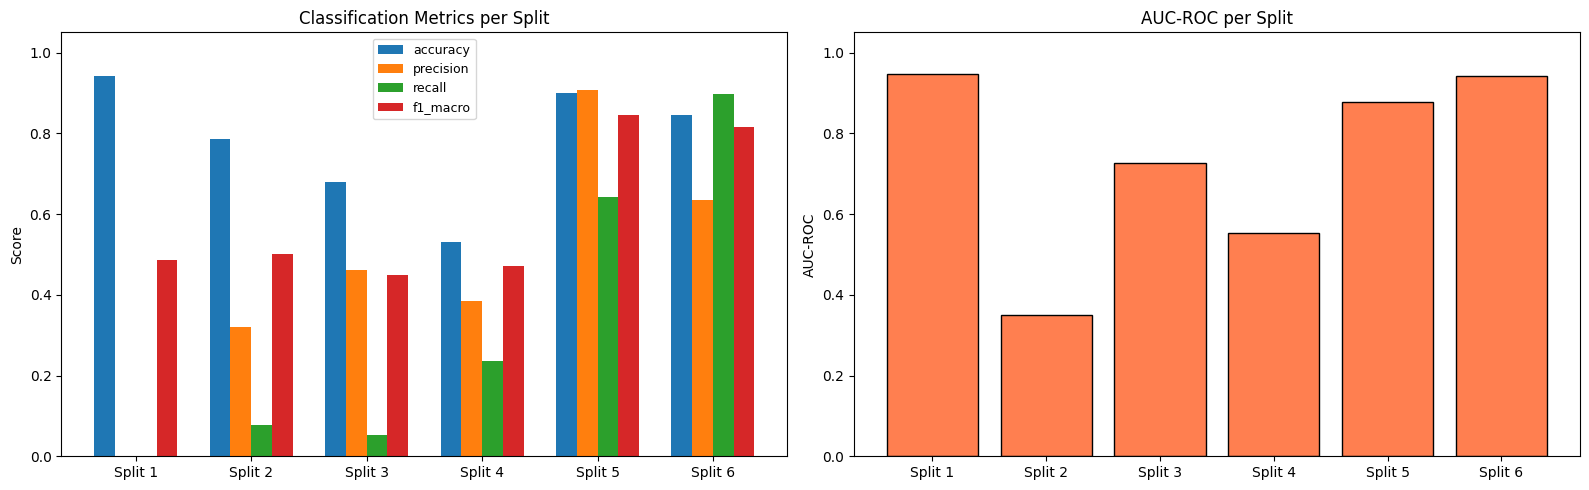

Saved → saved_model/metrics_per_split.png


In [9]:
# ──────────────────────────────────────────────
# Cell 8 – Bar chart of metrics per split
# ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 8a – Grouped bar: Accuracy / Precision / Recall / F1-macro per split
bar_cols = ["accuracy", "precision", "recall", "f1_macro"]
x = np.arange(len(df_metrics))
width = 0.18
for i, col in enumerate(bar_cols):
    axes[0].bar(x + i * width, df_metrics[col], width, label=col)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels([f"Split {r['split']}" for _, r in df_metrics.iterrows()])
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Classification Metrics per Split")
axes[0].legend(fontsize=9)
axes[0].set_ylabel("Score")

# 8b – AUC-ROC per split
axes[1].bar(x, df_metrics["auc_roc"], color="coral", edgecolor="k")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Split {r['split']}" for _, r in df_metrics.iterrows()])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("AUC-ROC per Split")
axes[1].set_ylabel("AUC-ROC")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "metrics_per_split.png"), dpi=150)
plt.show()
print("Saved → saved_model/metrics_per_split.png")

## 8 · Save Final Model & Scaler (trained on all data 2015–2026)

In [ ]:
# ──────────────────────────────────────────────
# Cell 9 – Retrain final model on full dataset (2015-2026) & save artefacts
# ──────────────────────────────────────────────

# Fit scaler on ALL data (2015–2026)
final_scaler = MinMaxScaler(feature_range=(-1, 1))
final_scaler.fit(df_clean[FEATURES])

# Build sequences for all locations
X_all, y_all = [], []
for loc_name in df_clean["Location_Name"].unique():
    loc_df = df_clean[df_clean["Location_Name"] == loc_name].sort_values("Date")
    feat_scaled = final_scaler.transform(loc_df[FEATURES])
    labels = loc_df[TARGET].values
    X_seq, y_seq = make_sequences(feat_scaled, labels)
    X_all.append(X_seq)
    y_all.append(y_seq)

X_final = np.concatenate(X_all)
y_final = np.concatenate(y_all)
print(f"Final training set: {X_final.shape}")
print(f"Date range: {df_clean['Date'].min()} → {df_clean['Date'].max()}")

# Class weights (inverse-frequency)
n_neg = int((y_final == 0).sum())
n_pos = int((y_final == 1).sum())
total = n_neg + n_pos
w_neg = total / (2.0 * n_neg) if n_neg > 0 else 1.0
w_pos = total / (2.0 * n_pos) if n_pos > 0 else 1.0
cw_final = {0: w_neg, 1: w_pos}
print(f"Class weights — 0: {w_neg:.3f}  1: {w_pos:.3f}")

# Train
K.clear_session()
tf.random.set_seed(SEED)
final_model = build_lstm_model(n_features=len(FEATURES))
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=binary_focal_loss(alpha=0.25, gamma=2.0),
    metrics=["accuracy"],
)

val_cut = int(len(X_final) * 0.9)
history_final = final_model.fit(
    X_final[:val_cut], y_final[:val_cut],
    validation_data=(X_final[val_cut:], y_final[val_cut:]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw_final,
    callbacks=[
        callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=4, min_lr=1e-6, verbose=1),
    ],
    verbose=1,
)

# Save model and scaler
model_path = os.path.join(MODEL_DIR, "haribon_lstm_risk.keras")
scaler_path = os.path.join(MODEL_DIR, "feature_scaler.joblib")

final_model.save(model_path)
joblib.dump(final_scaler, scaler_path)

print(f"✅  Model  saved → {model_path}")
print(f"✅  Scaler saved → {scaler_path}")